In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np

%matplotlib inline

df=pd.read_csv('diamonds.csv')
print('Shape before deleting duplicate values:', df.shape)

# Removing duplicate rows if any
df=df.drop_duplicates()
print('Shape After deleting duplicate values:', df.shape)

df.head(10)

Shape before deleting duplicate values: (53940, 11)
Shape After deleting duplicate values: (53940, 11)


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


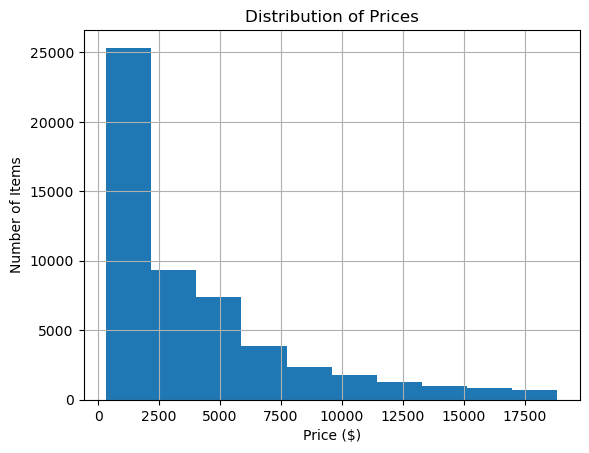

In [3]:

# Bar chart for Continuous target var
import matplotlib.pyplot as plt

df['price'].hist()

plt.xlabel('Price ($)')          # Labels the horizontal axis
plt.ylabel('Number of Items')     # Labels the vertical axis
plt.title('Distribution of Prices') # Adds a title to the top

plt.show() 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
df.describe(include='all')

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,26970.500000,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In [6]:
df.nunique()

Unnamed: 0    53940
carat           273
cut               5
color             7
clarity           8
depth           184
table           127
price         11602
x               554
y               552
z               375
dtype: int64

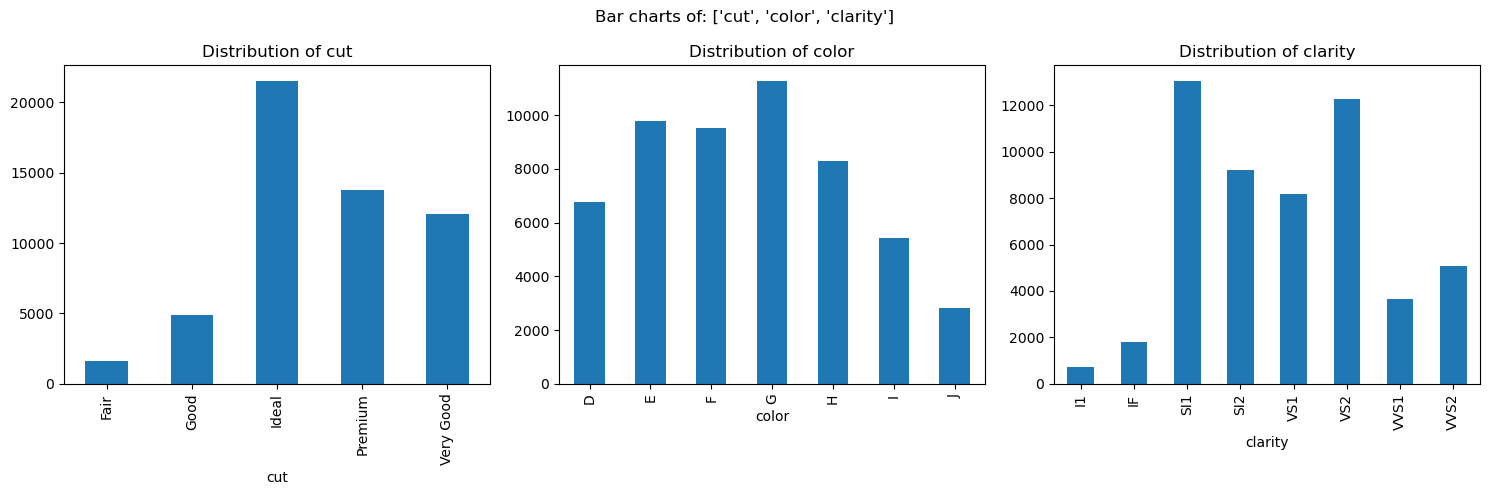

In [7]:
import matplotlib.pyplot as plt

def PlotBarCharts(inpData, colsToPlot):
    # ensure colsToPlot is a list, even if a single string is passed
    if isinstance(colsToPlot, str):
        colsToPlot = [colsToPlot]
        
    num_cols = len(colsToPlot)
    
    fig, subPlot = plt.subplots(nrows=1, ncols=num_cols, figsize=(5 * num_cols, 5))
    fig.suptitle('Bar charts of: ' + str(colsToPlot))
    
    # wrap subPlot in a list if it's just a single axes object
    if num_cols == 1:
        subPlot = [subPlot]

    # loop and plot
    for colName, plotNumber in zip(colsToPlot, range(num_cols)):
        inpData.groupby(colName).size().plot(kind='bar', ax=subPlot[plotNumber])
        subPlot[plotNumber].set_title(f'Distribution of {colName}')
        
    plt.tight_layout() # prevents labels from overlapping
    plt.show()
    
PlotBarCharts(df, ['cut', 'color', 'clarity']) # calls the function

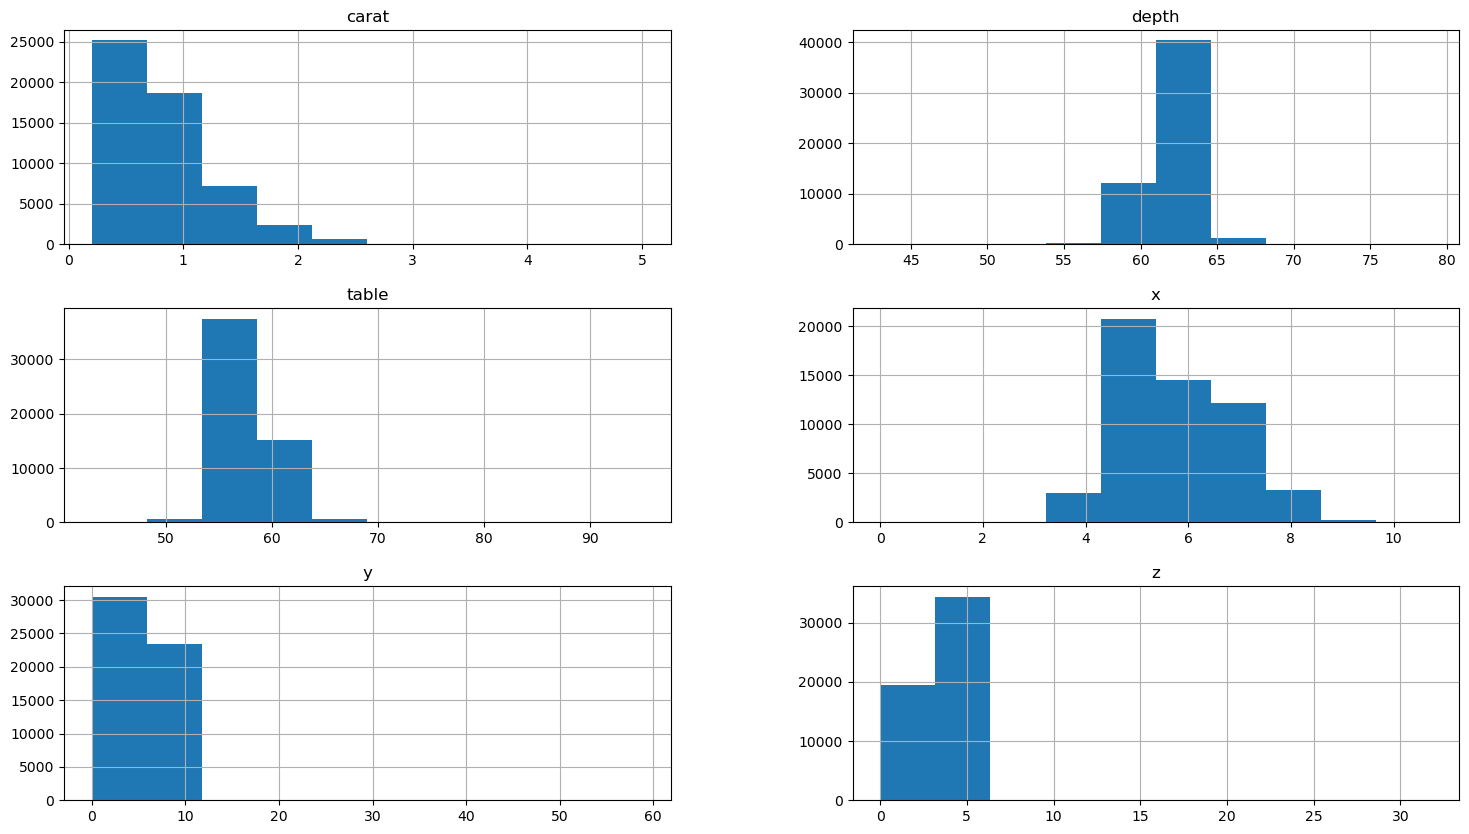

In [8]:
df.hist(['carat', 'depth', 'table', 'x','y','z'], figsize=(18,10)); # semicolon supresses this from being shown
plt.show() # forces showing plots

In [9]:
df.loc[df['x'] >= 0.001, 'x'].sort_values(ascending=True) # this should identify any minimum non-zero values

31596     3.73
31600     3.73
31598     3.74
31599     3.76
31601     3.77
         ...  
26444    10.01
25999    10.02
25998    10.14
27630    10.23
27415    10.74
Name: x, Length: 53932, dtype: float64

In [10]:
df.loc[df['x'] < 3.73, 'x'] = 3.73 # replace any value below 3.73

In [11]:
df.loc[df['y'] < 40, 'y'].sort_values(ascending=False)

49189    31.80
27415    10.54
27630    10.16
25998    10.10
25999     9.94
         ...  
49556     0.00
11963     0.00
15951     0.00
26243     0.00
24520     0.00
Name: y, Length: 53939, dtype: float64

In [12]:
df.loc[df['y'] > 20, 'y'] = 10.54 # replace any value above 10.54

In [13]:
df.loc[df['z'] < 10, 'z'].sort_values(ascending=False)

24067    8.06
27415    6.98
27630    6.72
27130    6.43
23644    6.38
         ... 
49557    0.00
26123    0.00
26243    0.00
2314     0.00
2207     0.00
Name: z, Length: 53939, dtype: float64

In [14]:
df.loc[df['z'] > 6.98, 'z'] = 6.98

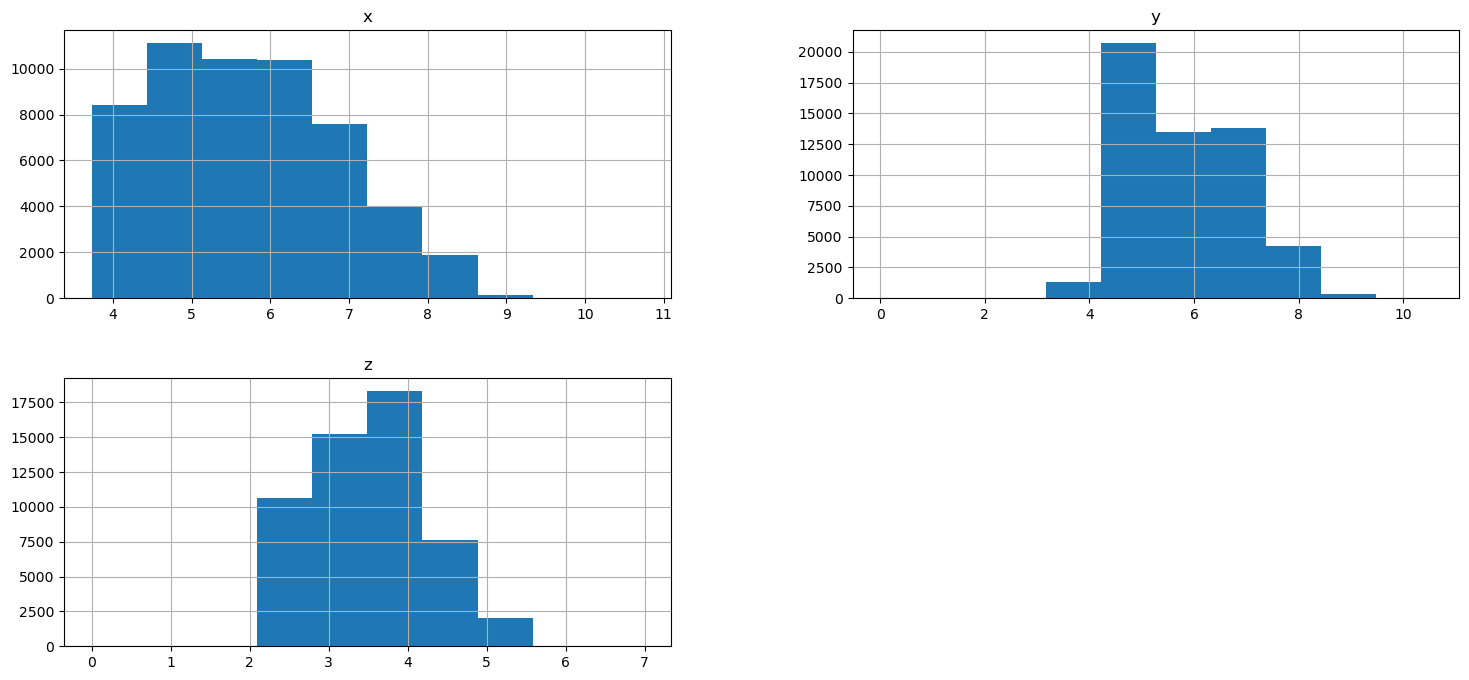

In [15]:
df.hist(['x', 'y', 'z'], figsize = (18, 8));
plt.show()

In [16]:
df.loc[df['y'] > 0.001, 'y'].sort_values(ascending=False) # find minimum non-zero values

24067    10.54
27415    10.54
49189    10.54
27630    10.16
25998    10.10
         ...  
31599     3.73
31601     3.72
31598     3.71
31596     3.71
31600     3.68
Name: y, Length: 53933, dtype: float64

In [17]:
df.loc[df['y'] < 3.68, 'y'] = 3.68 # replace any value below 3.68

In [18]:
df.loc[df['z'] > 2, 'z'].sort_values(ascending=True)

39246    2.06
31592    2.24
47138    2.25
31591    2.26
14       2.27
         ... 
27130    6.43
27630    6.72
27415    6.98
24067    6.98
48410    6.98
Name: z, Length: 53917, dtype: float64

In [19]:
df.loc[df['z'] < 2, 'z'] = 2.06

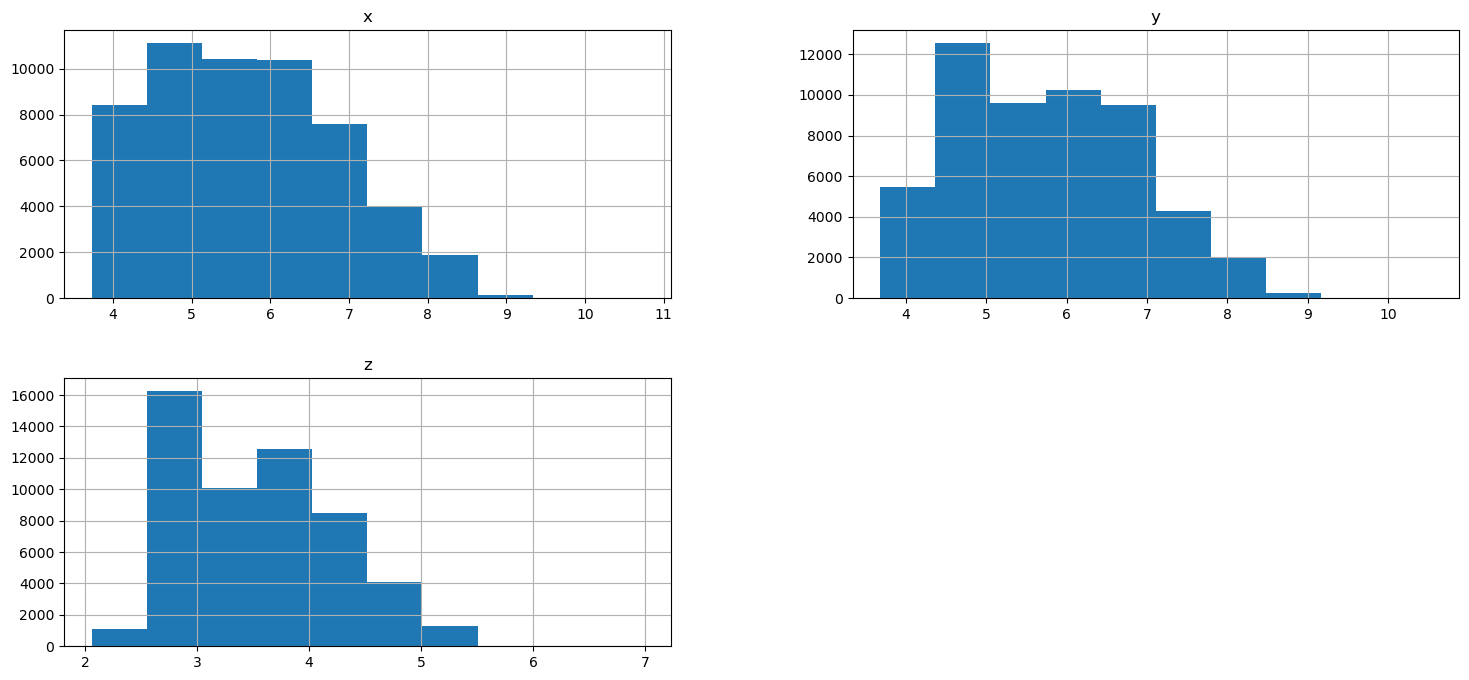

In [20]:
df.hist(['x','y', 'z'], figsize=(18,8));
plt.show()

In [21]:
df.isnull().sum() #check for missing row values

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

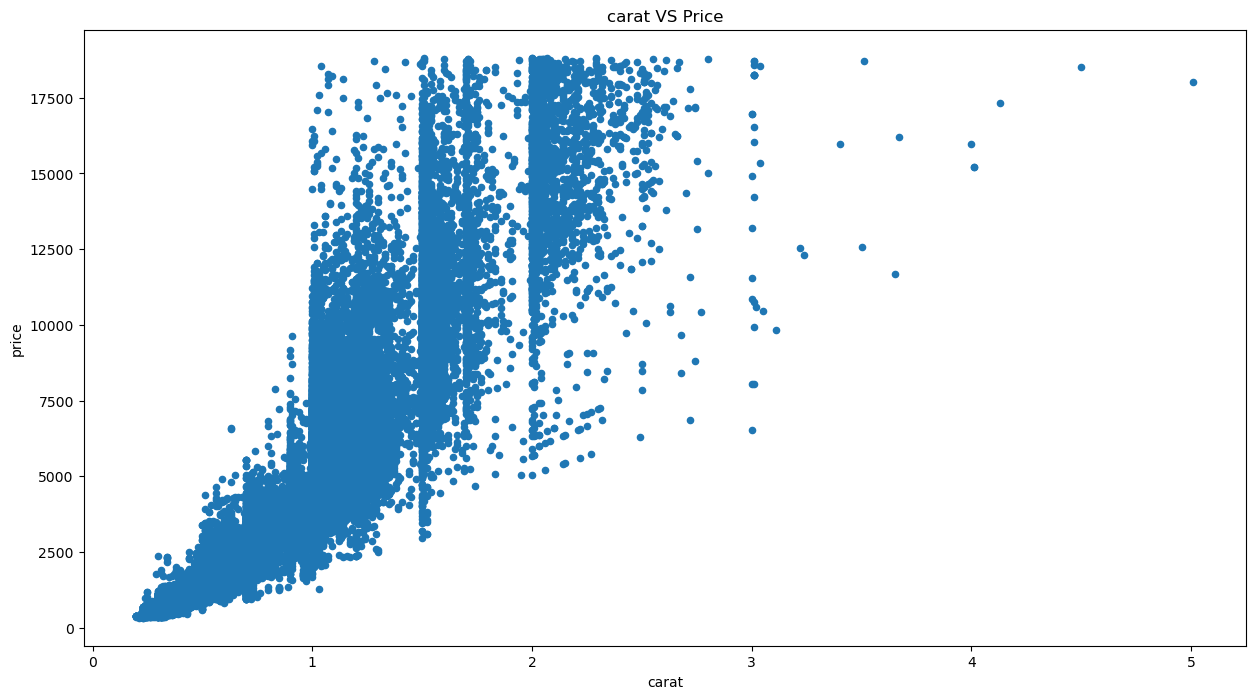

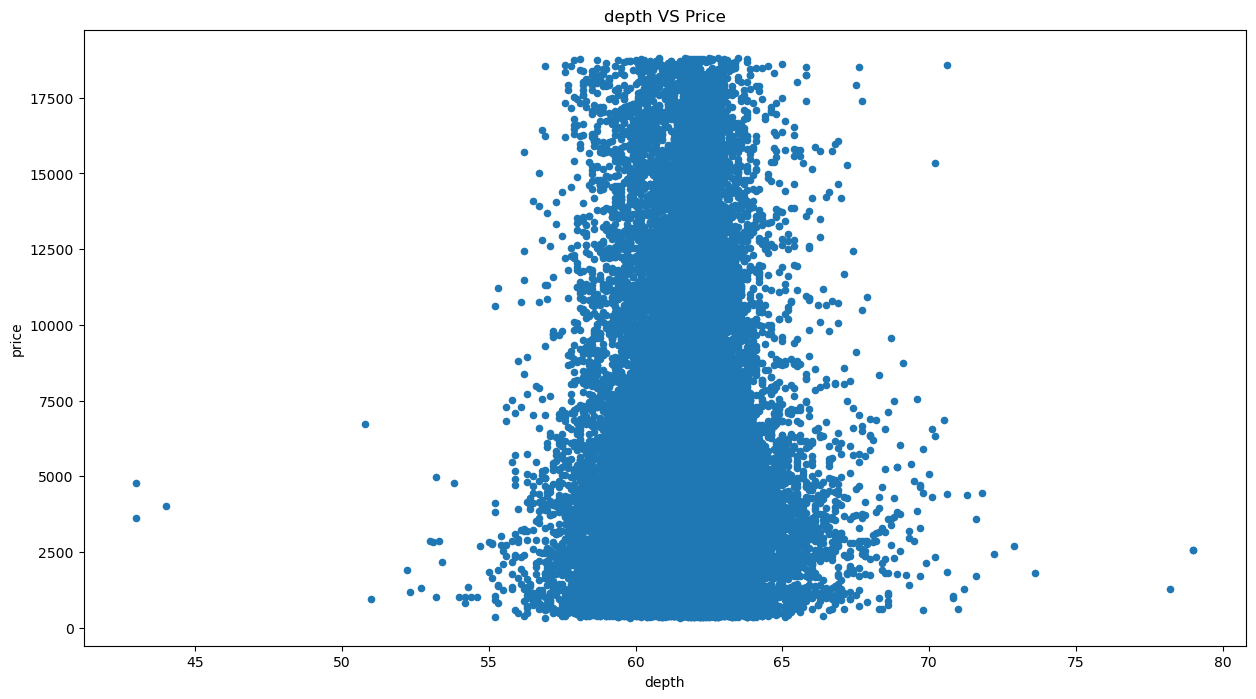

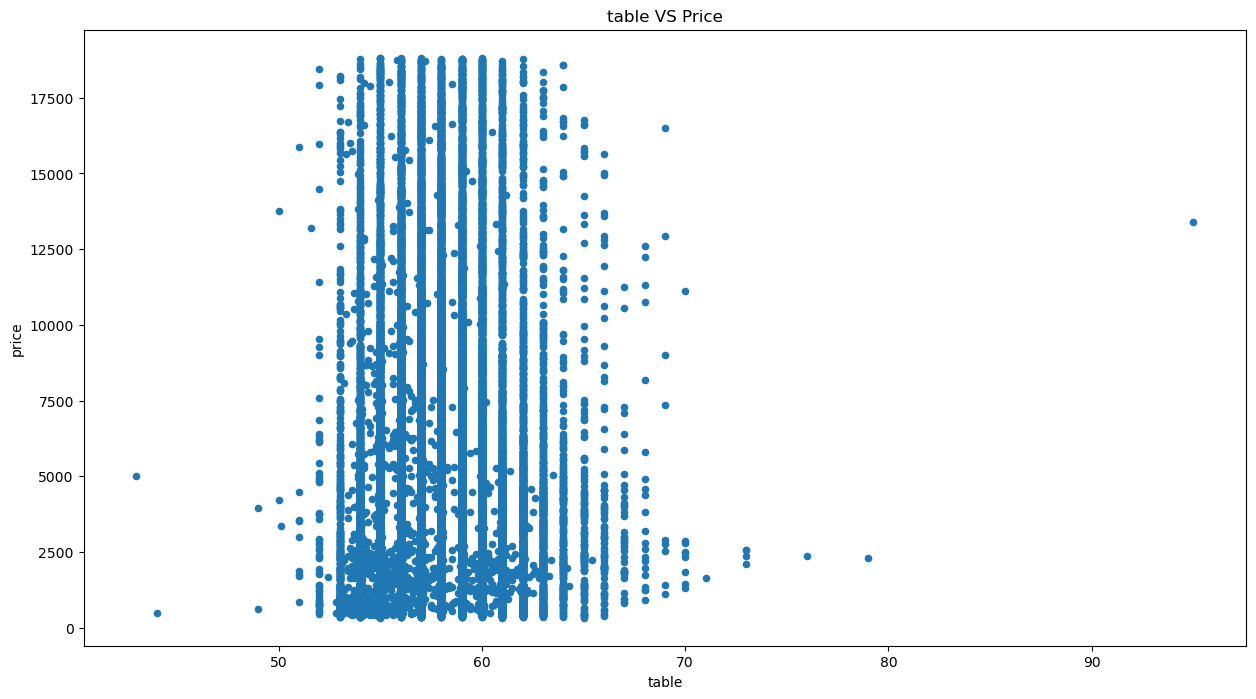

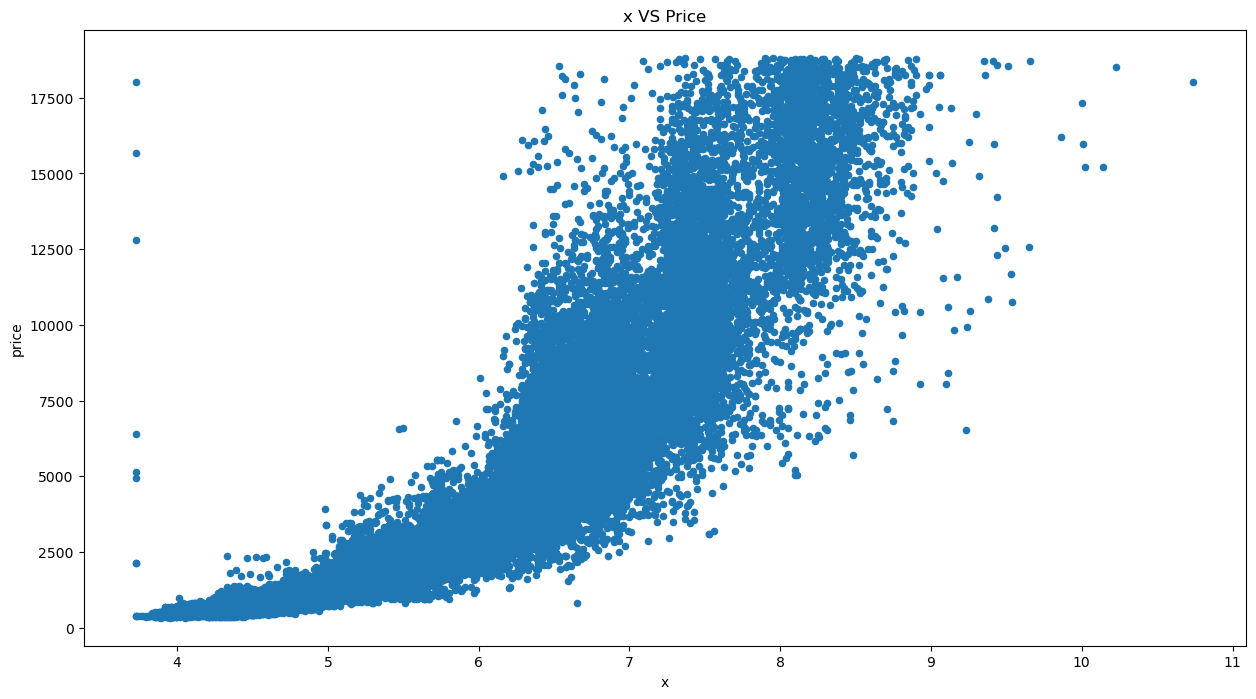

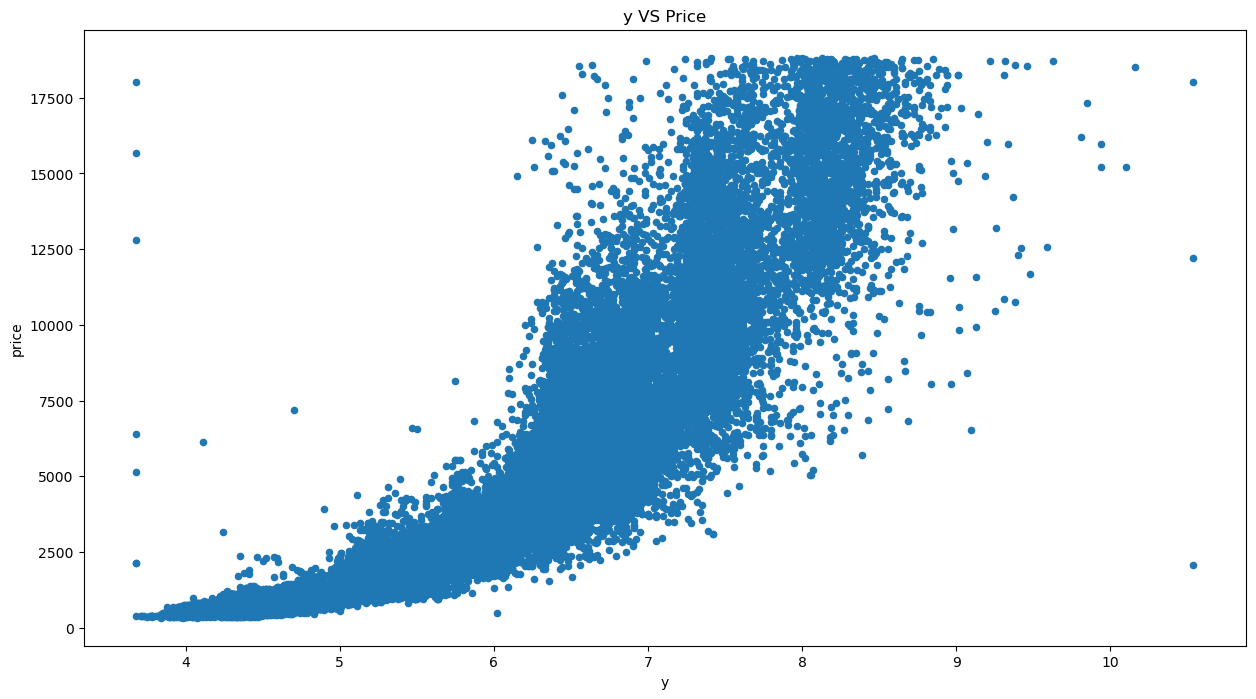

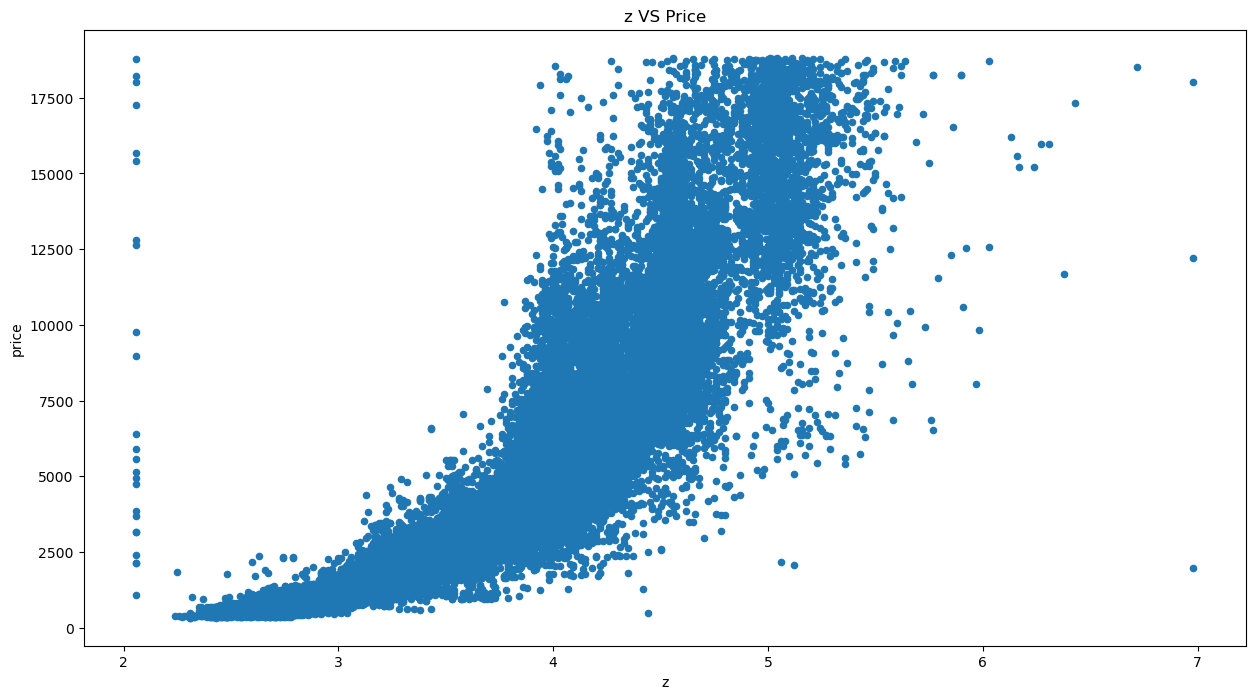

In [22]:
ContCols=['carat', 'depth', 'table', 'x','y','z']

# Plotting scatter chart for each predictor vs the target variable
for predictor in ContCols:
    df.plot.scatter(x=predictor, y='price', figsize=(15,8), title=predictor+" VS "+ 'Price');
    plt.show()

In [23]:
zFilter = (df['z']>2.2) & (df['z']<6.2) # tightens z variaable to further remove outliers
df = df[zFilter]

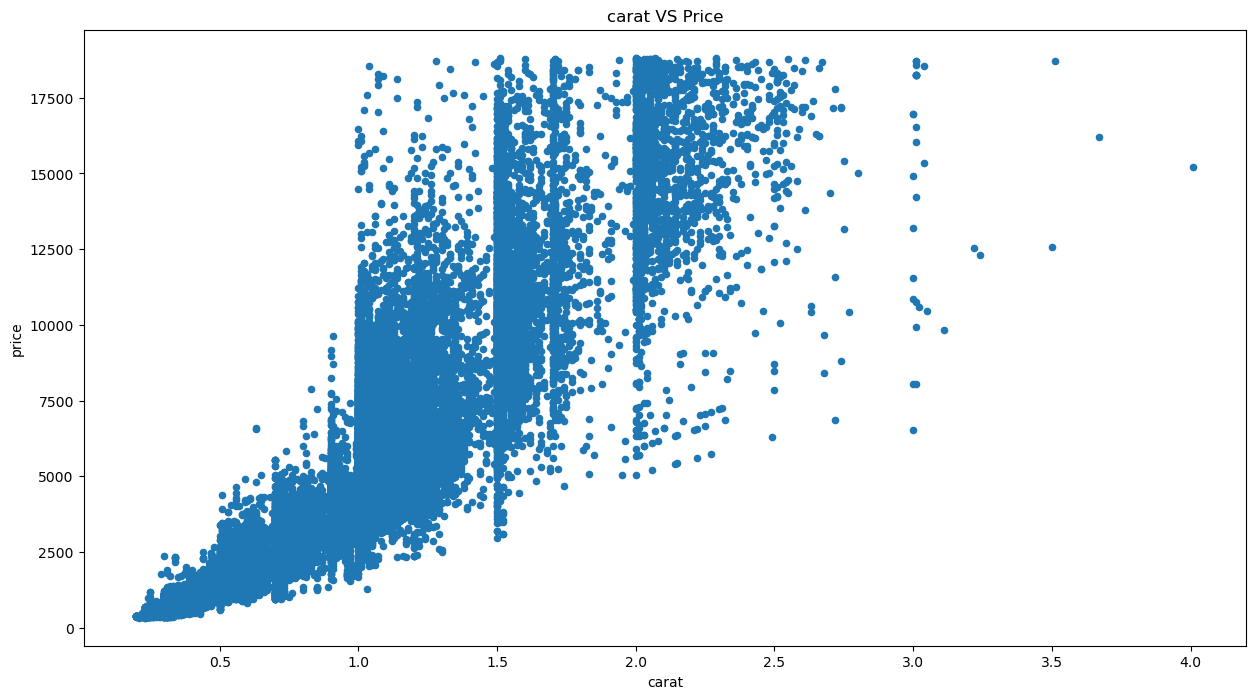

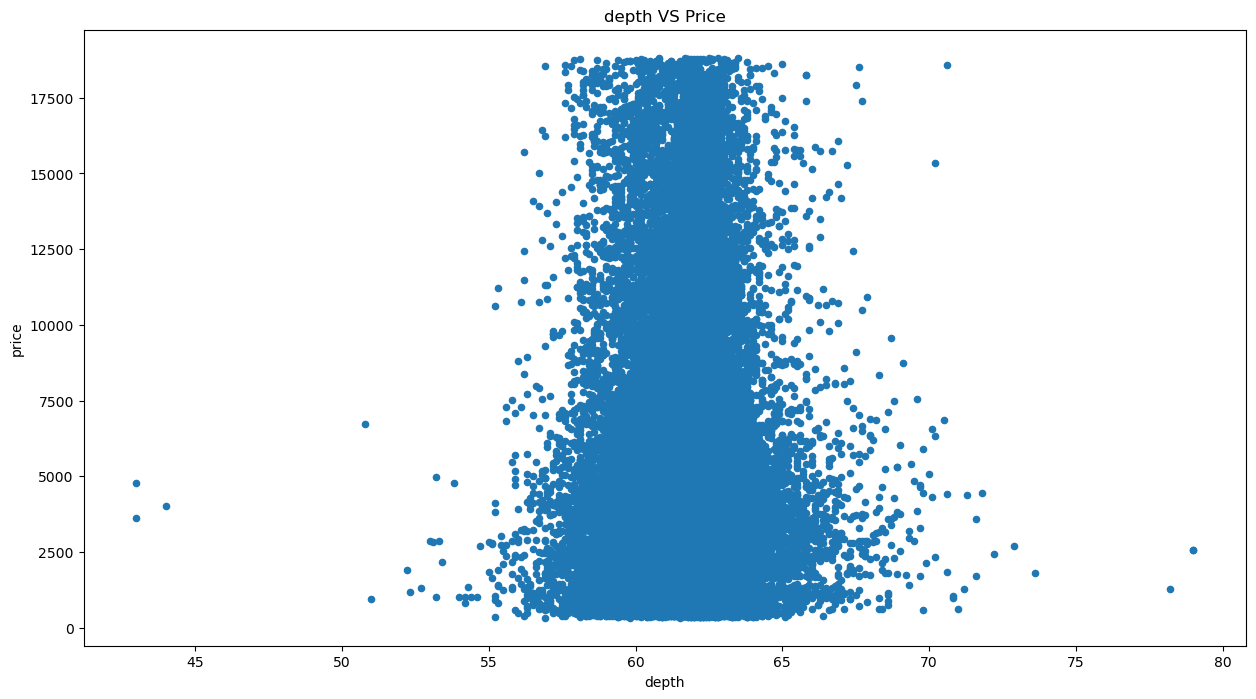

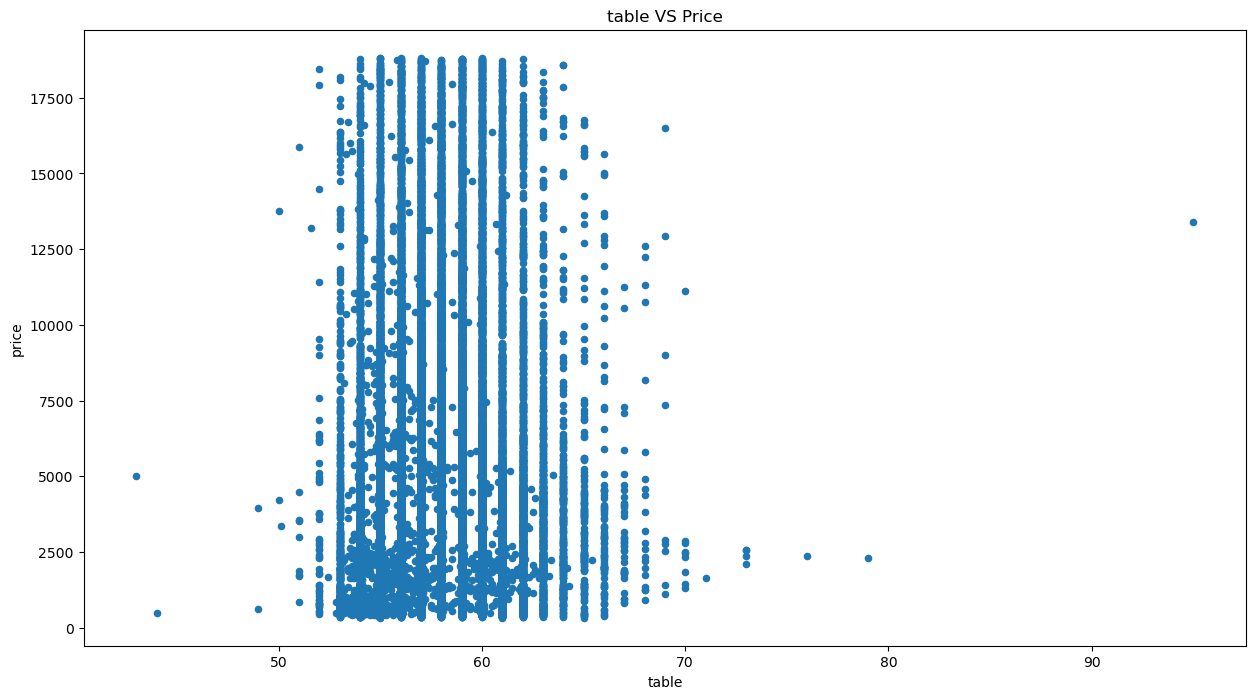

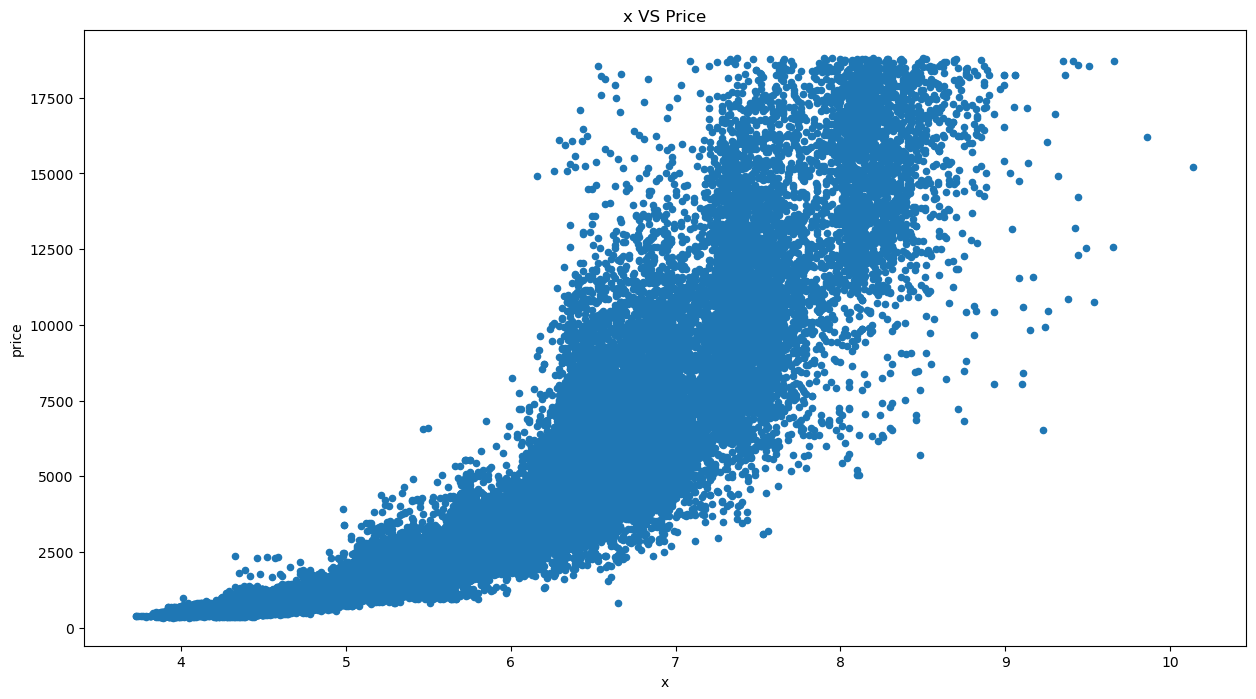

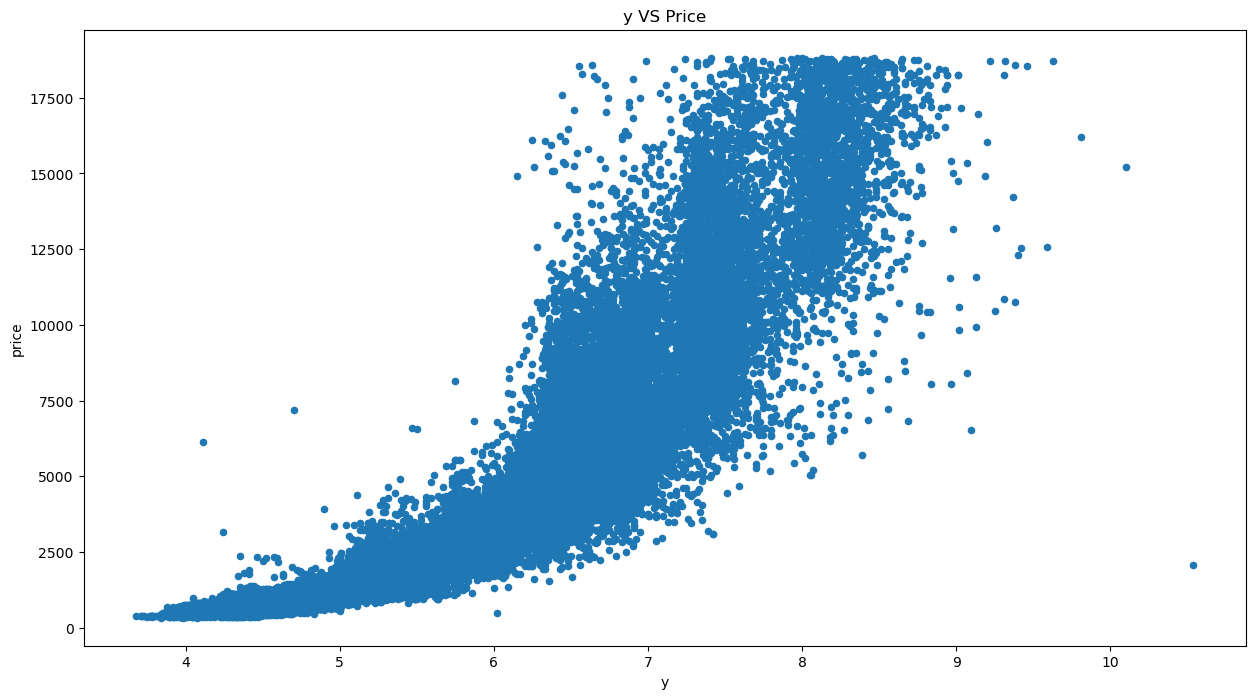

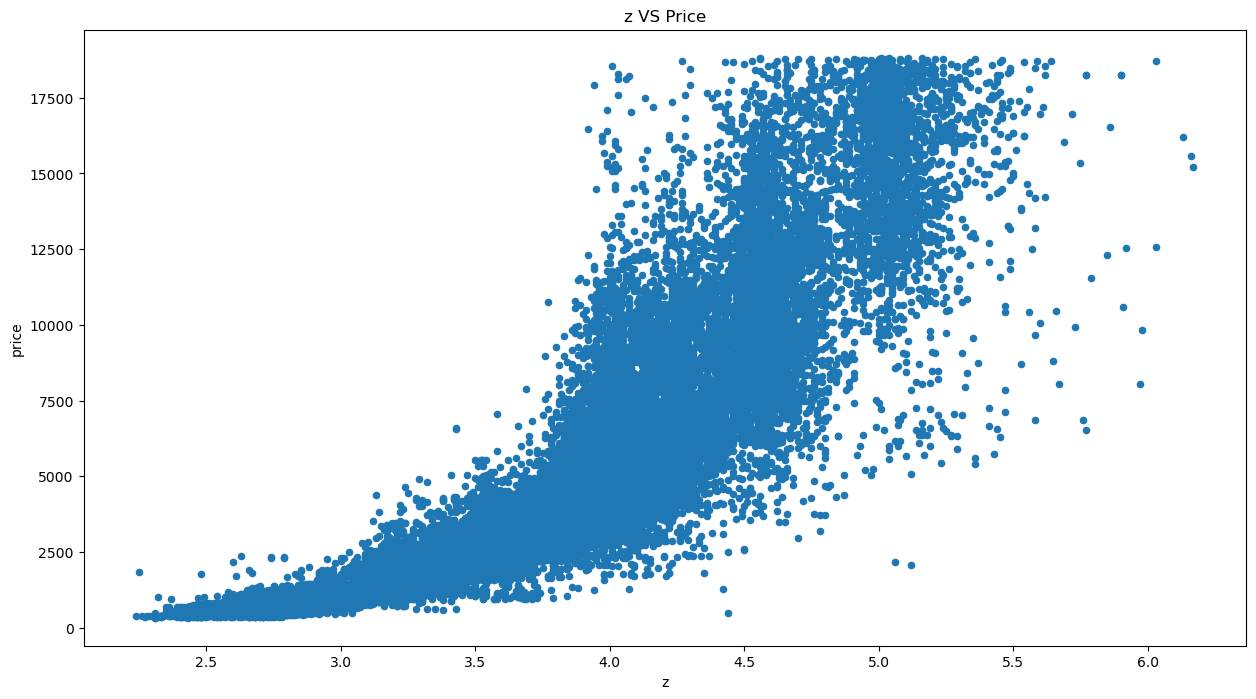

In [24]:
ContCols=['carat', 'depth', 'table', 'x','y','z']

# Plotting scatter chart for each predictor vs the target variable
for predictor in ContCols:
    df.plot.scatter(x=predictor, y='price', figsize=(15,8), title=predictor+" VS "+ 'Price');
    plt.show()

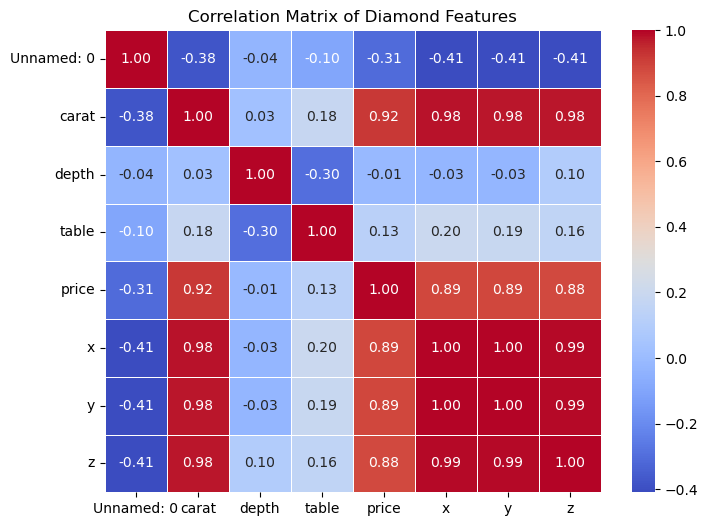

price    1.000000
carat    0.922321
x        0.887082
y        0.888486
z        0.882417
Name: price, dtype: float64

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# generate a visual heatmap of your correlation matrix
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
Correlation = numeric_df.corr()

# Your exact heatmap code will now work perfectly:
sns.heatmap(Correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Diamond Features')
plt.show()

# calculating correlation matrix
ContCols=['price','carat', 'depth', 'table', 'x','y','z']

# creating the correlation matrix
CorrelationData=df[ContCols].corr()

CorrelationData['price'][abs(CorrelationData['price']) > 0.7 ] # 0.7 to 1.0 is strong correlation

Stromgest correlation between price and carat, x, y, z for the continuous data

Categorical Data

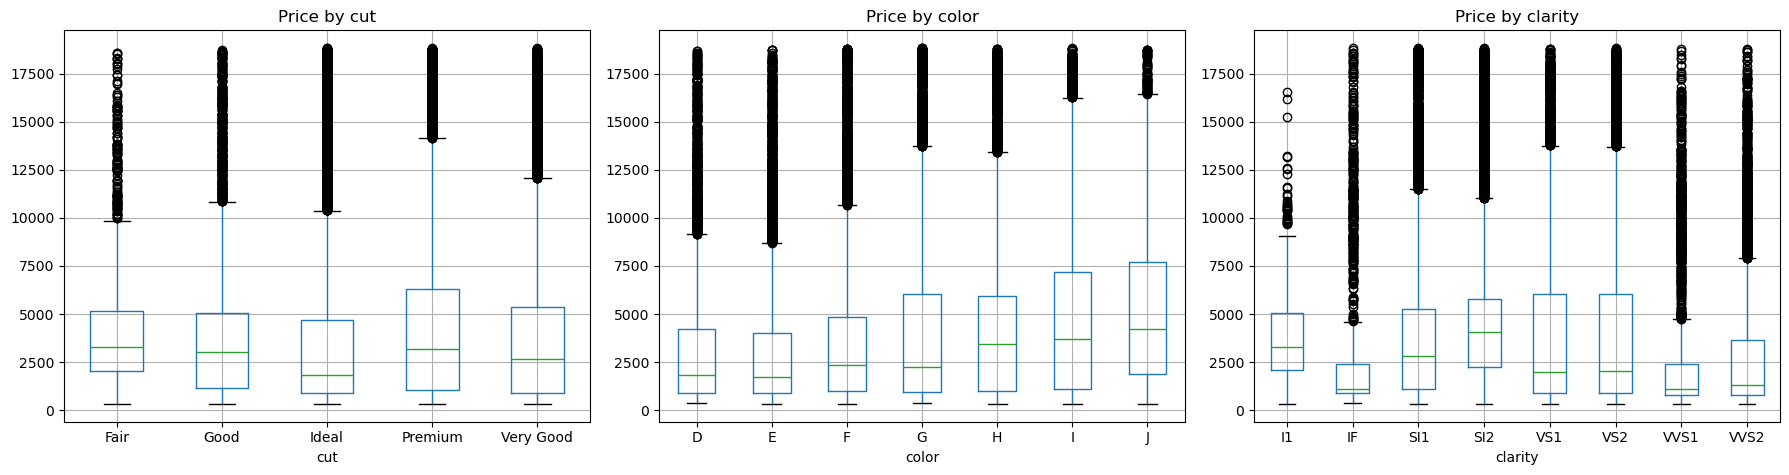

In [26]:
import matplotlib.pyplot as plt

Cat_List = ['cut', 'color', 'clarity']

# create the subplots canvas
fig, PlotCanvas = plt.subplots(nrows=1, ncols=len(Cat_List), figsize=(18, 5))

# loop through and assign each boxplot to its respective axis
for i, PredictorCol in enumerate(Cat_List):
    df.boxplot(column='price', by=PredictorCol, vert=True, ax=PlotCanvas[i])
    PlotCanvas[i].set_title(f'Price by {PredictorCol}')  # clean custom title

# clean up default pandas titles and adjust spacing
plt.suptitle('')  # Removes the default "Boxplot grouped by..." text
plt.tight_layout()

# display the complete figure ONCE after the loop finishes
plt.show()

In [27]:
def FunctionAnova(inpData, TargetVariable, CategoricalPredictorList):
    from scipy.stats import f_oneway

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]
    
    print('##### ANOVA Results ##### \n')
    for predictor in CategoricalPredictorList:
        CategoryGroupLists=inpData.groupby(predictor)[TargetVariable].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)
        
        # If the ANOVA P-Value is <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
    
    return(SelectedPredictors)

CategoricalPredictorList=['cut', 'color', 'clarity']
FunctionAnova(inpData=df, 
              TargetVariable='price', 
              CategoricalPredictorList=CategoricalPredictorList)

##### ANOVA Results ##### 

cut is correlated with price | P-Value: 3.477910867055907e-148
color is correlated with price | P-Value: 0.0
clarity is correlated with price | P-Value: 1.38553645e-316


['cut', 'color', 'clarity']

ANOVA confirms visual analysis of correlation in box plots.

In [28]:
DataForModel = df[['carat', 'x', 'y', 'z', 'cut', 'color', 'clarity']]
DataForModel.head(10)

,carat,x,y,z,cut,color,clarity
0,0.23,3.95,3.98,2.43,Ideal,E,SI2
1,0.21,3.89,3.84,2.31,Premium,E,SI1
2,0.23,4.05,4.07,2.31,Good,E,VS1
3,0.29,4.20,4.23,2.63,Premium,I,VS2
4,0.31,4.34,4.35,2.75,Good,J,SI2
5,0.24,3.94,3.96,2.48,Very Good,J,VVS2
6,0.24,3.95,3.98,2.47,Very Good,I,VVS1
7,0.26,4.07,4.11,2.53,Very Good,H,SI1
8,0.22,3.87,3.78,2.49,Fair,E,VS2
9,0.23,4.00,4.05,2.39,Very Good,H,VS1


In [29]:
DataForModel['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [30]:
DataForModel['cut'].replace({'Good':1, 'Very Good':2, 'Fair':3, 'Ideal':4, 'Premium':5}, inplace=True)

In [31]:
DataForModel['color'].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [32]:
DataForModel['color'].replace({'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}, inplace=True)

In [33]:
DataForModel['clarity'].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [34]:
DataForModel['clarity'].replace({'I1':1, 'SI1':2, 'SI2':3, 'VS1':4, 'VS2':5, 'VVS1':6, 'VVS2':7, 'IF':8}, inplace=True)

In [35]:
# Treating all the nominal variables at once using dummy variables
DataForMdl_Numeric=pd.get_dummies(DataForModel)

# Adding Target Variable to the data
DataForMdl_Numeric['price']=df['price']

# Printing sample rows
DataForMdl_Numeric.head()

,carat,x,y,z,cut,color,clarity,price
0,0.23,3.95,3.98,2.43,4,6,3,326
1,0.21,3.89,3.84,2.31,5,6,2,326
2,0.23,4.05,4.07,2.31,1,6,4,327
3,0.29,4.20,4.23,2.63,5,2,5,334
4,0.31,4.34,4.35,2.75,1,1,3,335


In [36]:
DataForMdl_Numeric.columns

Index(['carat', 'x', 'y', 'z', 'cut', 'color', 'clarity', 'price'], dtype='object')

In [37]:
TargetVariable='price'
Predictors=['carat', 'x', 'y', 'z', 'cut', 'color', 'clarity']

X=DataForMdl_Numeric[Predictors].values
y=DataForMdl_Numeric[TargetVariable].values

# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [38]:
### Sandardization of data ###
from sklearn.preprocessing import MinMaxScaler

PredictorScaler=MinMaxScaler()

PredictorScalerFit=PredictorScaler.fit(X)

# Generating the standardized values of X
X=PredictorScalerFit.transform(X)

# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [39]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(37734, 7)
(37734,)
(16173, 7)
(16173,)


In [40]:
# Multiple Linear Regression
from sklearn.linear_model import LinearRegression
RegModel = LinearRegression()

# Printing all the parameters of Linear regression
print(RegModel)

# Creating the model on Training Data
LREG=RegModel.fit(X_train,y_train)
prediction=LREG.predict(X_test)

# Taking the standardized values to original scale


from sklearn import metrics
# Measuring Goodness of fit in Training data
print('R2 Value:',metrics.r2_score(y_train, LREG.predict(X_train)))

###########################################################################
print('\n##### Model Validation ##########')

# Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=Predictors)
TestingDataResults[TargetVariable]=y_test
TestingDataResults[('Predicted'+TargetVariable)]=np.round(prediction)

# Printing sample prediction values
print(TestingDataResults[[TargetVariable,'Predicted'+TargetVariable]].head())

# Calculating the error for each row
TestingDataResults['APE']=100 * ((abs(
  TestingDataResults['price']-TestingDataResults['Predictedprice']))/TestingDataResults['price'])

MAPE=np.mean(TestingDataResults['APE'])
MedianMAPE=np.median(TestingDataResults['APE'])

Accuracy =100 - MAPE
MedianAccuracy=100- MedianMAPE
print('Mean Accuracy on test data:', Accuracy) # Can be negative sometimes due to outlier
print('Median Accuracy on test data:', MedianAccuracy)

LinearRegression()
R2 Value: 0.897383407655864

##### Model Validation ##########
   price  Predictedprice
0  16583         12254.0
1    523           114.0
2    687           468.0
3  14452         15446.0
4    698           274.0
Mean Accuracy on test data: 60.090401920477035
Median Accuracy on test data: 77.64091858037578


In [41]:
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor

# 1. FIXED: Changed criterion to 'squared_error' to prevent ValueError
RegModel = DecisionTreeRegressor(max_depth=10, criterion="squared_error")

# Printing all the parameters of Decision Tree
print(RegModel)

# Creating the model on Training Data
DT = RegModel.fit(X_train, y_train)
prediction = DT.predict(X_test)

# Measuring Goodness of fit in Training data
print("R2 Value:", metrics.r2_score(y_train, DT.predict(X_train)))

# Plotting the feature importance for Top 10 most important columns
# Note: Ensure 'Predictors' is defined as a list of your feature column names
%matplotlib inline
feature_importances = pd.Series(DT.feature_importances_, index=Predictors)
feature_importances.nlargest(10).plot(kind="barh")

###########################################################################
print("\n##### Model Validation and Accuracy Calculations ##########")

# Printing some sample values of prediction
TestingDataResults = pd.DataFrame(data=X_test, columns=Predictors)

# Note: Ensure 'TargetVariable' is defined as a string (e.g., TargetVariable = 'price')
TestingDataResults[TargetVariable] = y_test
TestingDataResults[("Predicted" + TargetVariable)] = np.round(prediction)

# Printing sample prediction values
print(TestingDataResults[[TargetVariable, "Predicted" + TargetVariable]].head())

# Calculating the error for each row
# Note: We use the dynamic TargetVariable and Predicted names here to stay consistent
actual_col = TargetVariable
predicted_col = "Predicted" + TargetVariable

TestingDataResults["APE"] = (
    100
    * (abs(TestingDataResults[actual_col] - TestingDataResults[predicted_col]))
    / TestingDataResults[actual_col]
)

MAPE = np.mean(TestingDataResults["APE"])
MedianMAPE = np.median(TestingDataResults["APE"])

Accuracy = 100 - MAPE
MedianAccuracy = 100 - MedianMAPE
print(
    "Mean Accuracy on test data:", Accuracy
)  # Can be negative sometimes due to outliers
print("Median Accuracy on test data:", MedianAccuracy)


DecisionTreeRegressor(max_depth=10)
R2 Value: 0.9820850287220845

##### Model Validation and Accuracy Calculations ##########
   price  Predictedprice
0  16583         16384.0
1    523           597.0
2    687           794.0
3  14452         16296.0
4    698           693.0
Mean Accuracy on test data: 90.58632570313219
Median Accuracy on test data: 92.69311064718163


In [42]:
# Random Forest (Bagging of multiple Decision Trees)
from sklearn.ensemble import RandomForestRegressor
RegModel = RandomForestRegressor(max_depth=5, n_estimators=100, criterion='squared_error')

# Good range for max_depth: 2-10 and n_estimators: 100-1000

# Printing all the parameters of Random Forest
print(RegModel)

# Creating the model on Training Data
RF=RegModel.fit(X_train,y_train)
prediction=RF.predict(X_test)

from sklearn import metrics
# Measuring Goodness of fit in Training data
print('R2 Value:',metrics.r2_score(y_train, RF.predict(X_train)))

# Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=Predictors)
feature_importances.nlargest(10).plot(kind='barh')

###########################################################################
print('\n##### Model Validation and Accuracy Calculations ##########')

# Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=Predictors)
TestingDataResults[TargetVariable]=y_test
TestingDataResults[('Predicted'+TargetVariable)]=np.round(prediction)

# Printing sample prediction values
print(TestingDataResults[[TargetVariable,'Predicted'+TargetVariable]].head())

# Calculating the error for each row
TestingDataResults['APE']=100 * ((abs(
  TestingDataResults['price']-TestingDataResults['Predictedprice']))/TestingDataResults['price'])

MAPE=np.mean(TestingDataResults['APE'])
MedianMAPE=np.median(TestingDataResults['APE'])

Accuracy =100 - MAPE
MedianAccuracy=100- MedianMAPE
print('Mean Accuracy on test data:', Accuracy) # Can be negative sometimes due to outlier
print('Median Accuracy on test data:', MedianAccuracy)

RandomForestRegressor(max_depth=5)
R2 Value: 0.9470133612132416

##### Model Validation and Accuracy Calculations ##########
   price  Predictedprice
0  16583         14731.0
1    523           669.0
2    687           778.0
3  14452         15604.0
4    698           669.0
Mean Accuracy on test data: 84.4014271153865
Median Accuracy on test data: 87.87806620623958


In [43]:
# K-Nearest Neighbor(KNN)
from sklearn.neighbors import KNeighborsRegressor
RegModel = KNeighborsRegressor(n_neighbors=4)

# Printing all the parameters of KNN
print(RegModel)

# Creating the model on Training Data
KNN=RegModel.fit(X_train,y_train)
prediction=KNN.predict(X_test)

from sklearn import metrics
# Measuring Goodness of fit in Training data
print('R2 Value:',metrics.r2_score(y_train, KNN.predict(X_train)))

# Plotting the feature importance for Top 10 most important columns
# The variable importance chart is not available for KNN

###########################################################################
print('\n##### Model Validation and Accuracy Calculations ##########')

# Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=Predictors)
TestingDataResults[TargetVariable]=y_test
TestingDataResults[('Predicted'+TargetVariable)]=np.round(prediction)

# Printing sample prediction values
print(TestingDataResults[[TargetVariable,'Predicted'+TargetVariable]].head())

# Calculating the error for each row
TestingDataResults['APE']=100 * ((abs(
  TestingDataResults['price']-TestingDataResults['Predictedprice']))/TestingDataResults['price'])

MAPE=np.mean(TestingDataResults['APE'])
MedianMAPE=np.median(TestingDataResults['APE'])

Accuracy =100 - MAPE
MedianAccuracy=100- MedianMAPE
print('Mean Accuracy on test data:', Accuracy) # Can be negative sometimes due to outlier
print('Median Accuracy on test data:', MedianAccuracy)

KNeighborsRegressor(n_neighbors=4)
R2 Value: 0.9853308749593345

##### Model Validation and Accuracy Calculations ##########
   price  Predictedprice
0  16583         16539.0
1    523           517.0
2    687           690.0
3  14452         15430.0
4    698           654.0
Mean Accuracy on test data: 91.98381887503442
Median Accuracy on test data: 94.46628364076201
